# 121. セントロイド空間の幾何学的分析 — TurboQuant着想の射影ベース枝刈り探索

## 目的
- Voronoi分割（NB111-118）で有効性が確認されたセントロイドベースの枝刈りをさらに発展させる
- Google TurboQuant（ICLR 2026）の知見「適切な射影でベクトルが圧縮できる」を応用
- 複数の射影方法（ランダム回転、PCA、角度、セントロイド相対）で近傍/非近傍の分離能力を調査
- **問い**: 枝刈りに有効な低次元射影は存在するか？

## 0. セットアップ

In [1]:
import sys
import numpy as np
import time
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import roc_auc_score
from scipy import stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, '../src')
DATA_DIR = Path('../data')
np.random.seed(42)
rng = np.random.default_rng(42)

N_QUERIES = 200
TOP_K = 10
print(f'Configuration: N_QUERIES={N_QUERIES}, TOP_K={TOP_K}')

Configuration: N_QUERIES=200, TOP_K=10


## 1. データロード

In [2]:
# Embeddings
emb_en = np.load(DATA_DIR / '10k_e5_base_en_embeddings.npy')
emb_ja = np.load(DATA_DIR / '10k_e5_base_ja_embeddings.npy')
emb_all = np.vstack([emb_en, emb_ja])

# L2正規化
def normalize(X):
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    return X / np.clip(norms, 1e-10, None)

emb_en = normalize(emb_en)
emb_ja = normalize(emb_ja)
emb_all = normalize(emb_all)

# セントロイド
centroids = np.load(DATA_DIR / 'voronoi_centroids_256_e5base_mixed.npy')
centroids = normalize(centroids)

D = emb_en.shape[1]
print(f'EN: {emb_en.shape}, JA: {emb_ja.shape}, All: {emb_all.shape}')
print(f'Centroids: {centroids.shape}, D={D}')

# Ground truth: brute-force cosine top-K
query_indices_en = rng.choice(len(emb_en), N_QUERIES, replace=False)
query_indices_ja = rng.choice(len(emb_ja), N_QUERIES, replace=False)

def get_ground_truth(embeddings, query_indices, top_k=TOP_K):
    gt = {}
    for qi in query_indices:
        sims = embeddings @ embeddings[qi]
        sims[qi] = -1  # 自分自身を除外
        gt[qi] = set(np.argsort(sims)[-top_k:])
    return gt

gt_en = get_ground_truth(emb_en, query_indices_en)
gt_ja = get_ground_truth(emb_ja, query_indices_ja)
print(f'Ground truth computed: EN={len(gt_en)}, JA={len(gt_ja)} queries')

EN: (10000, 768), JA: (9990, 768), All: (19990, 768)
Centroids: (256, 768), D=768


Ground truth computed: EN=200, JA=200 queries


## 2. セントロイドの固有値構造分析

256個のセントロイドと20K個のembeddingそれぞれのPCA固有値構造を比較する。
セントロイド空間がどの程度低次元で説明できるかを確認。

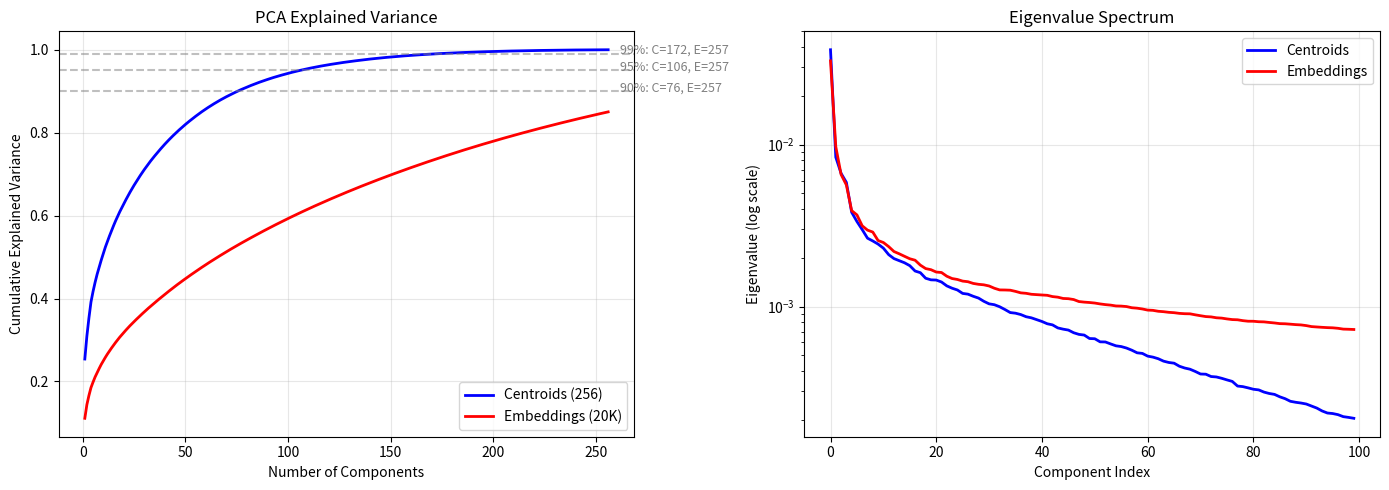

90% variance: Centroids=76D, Embeddings=257D
95% variance: Centroids=106D, Embeddings=257D
99% variance: Centroids=172D, Embeddings=257D

Condition number: Centroids=1365349629952.0, Embeddings=101.0


In [3]:
# PCA: セントロイド vs 全embedding
pca_centroids = PCA().fit(centroids)
pca_embeddings = PCA(n_components=256).fit(emb_all)  # 256次元まで

cumvar_c = np.cumsum(pca_centroids.explained_variance_ratio_)
cumvar_e = np.cumsum(pca_embeddings.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 累積分散説明率
axes[0].plot(range(1, len(cumvar_c)+1), cumvar_c, 'b-', label='Centroids (256)', linewidth=2)
axes[0].plot(range(1, len(cumvar_e)+1), cumvar_e, 'r-', label='Embeddings (20K)', linewidth=2)
for thresh in [0.90, 0.95, 0.99]:
    axes[0].axhline(y=thresh, color='gray', linestyle='--', alpha=0.5)
    n_c = np.searchsorted(cumvar_c, thresh) + 1
    n_e = np.searchsorted(cumvar_e, thresh) + 1
    axes[0].annotate(f'{thresh:.0%}: C={n_c}, E={n_e}', xy=(max(n_c, n_e)+5, thresh),
                     fontsize=9, color='gray')
axes[0].set_xlabel('Number of Components')
axes[0].set_ylabel('Cumulative Explained Variance')
axes[0].set_title('PCA Explained Variance')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 固有値スペクトル（対数）
axes[1].semilogy(pca_centroids.explained_variance_[:100], 'b-', label='Centroids', linewidth=2)
axes[1].semilogy(pca_embeddings.explained_variance_[:100], 'r-', label='Embeddings', linewidth=2)
axes[1].set_xlabel('Component Index')
axes[1].set_ylabel('Eigenvalue (log scale)')
axes[1].set_title('Eigenvalue Spectrum')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# サマリ
for thresh in [0.90, 0.95, 0.99]:
    n_c = np.searchsorted(cumvar_c, thresh) + 1
    n_e = np.searchsorted(cumvar_e, thresh) + 1
    print(f'{thresh:.0%} variance: Centroids={n_c}D, Embeddings={n_e}D')

cond_c = pca_centroids.explained_variance_[0] / pca_centroids.explained_variance_[-1]
cond_e = pca_embeddings.explained_variance_[0] / pca_embeddings.explained_variance_[-1]
print(f'\nCondition number: Centroids={cond_c:.1f}, Embeddings={cond_e:.1f}')

## 3. ランダム回転後の座標分布（TurboQuant検証）

TurboQuantの核心的知見: L2正規化ベクトルにランダム直交回転を適用すると、
各座標がBeta(α, α)分布（α=(D-1)/2）に従い、座標間が近似的に独立になる。

D=768ではα=383.5で、ほぼ正規分布に近い集中したBeta分布になるはず。
ただし実際のE5 embeddingは球面上の一様分布ではないため、どの程度成立するか検証する。

Random orthogonal matrix R: (768, 768)
Orthogonality check: ||R@R.T - I||_F = 3.54e-14


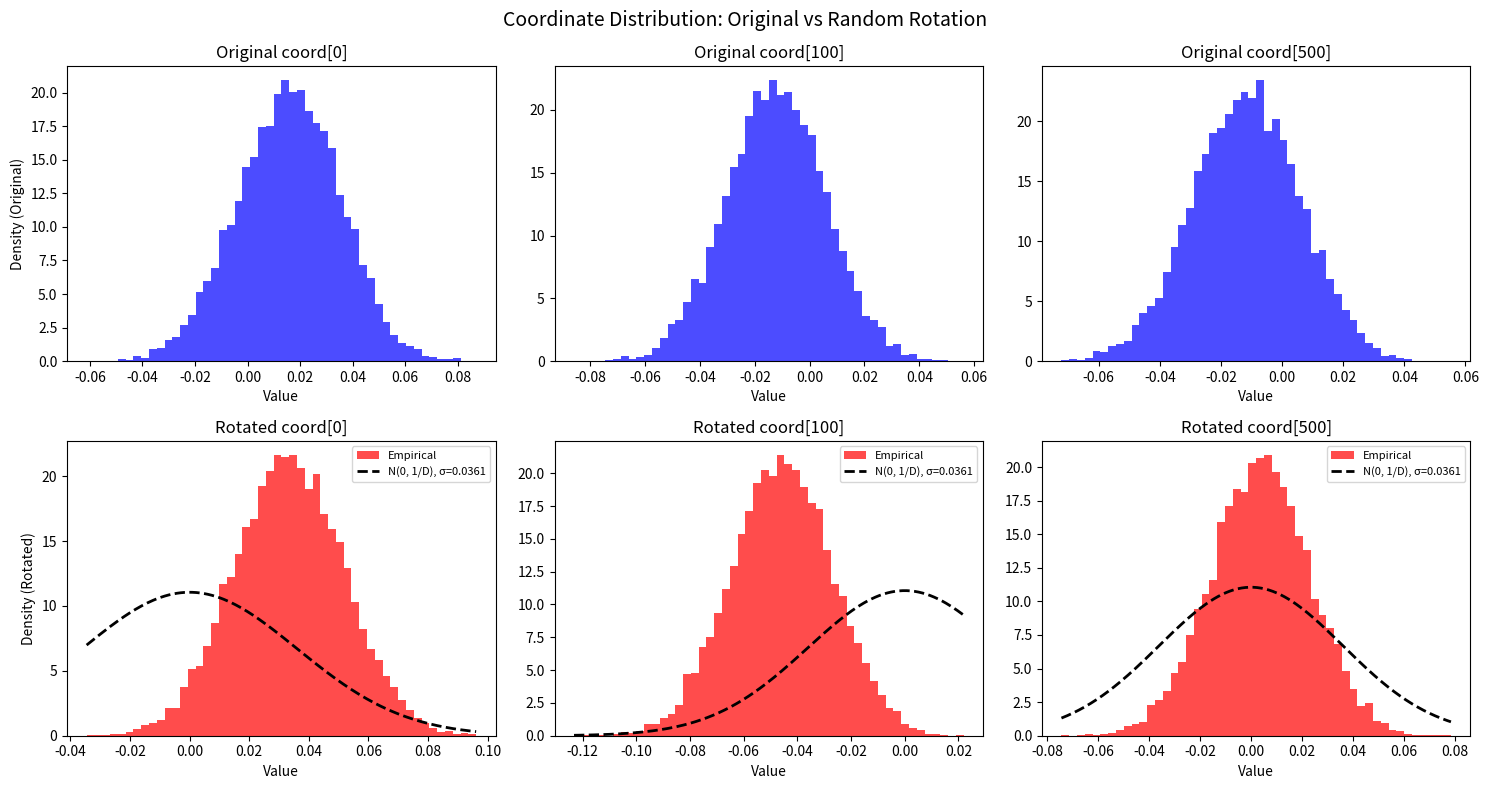


KS test (H0: rotated coords ~ N(0, 1/D)):
  p > 0.05: 0/100 coords
  p > 0.01: 0/100 coords
  Mean p-value: 0.0000

Mean |correlation| (first 20 coords):
  Original: 0.0481
  Rotated:  0.0488


In [4]:
# ランダム直交行列の生成（QR分解）
R = stats.ortho_group.rvs(D, random_state=42)
print(f'Random orthogonal matrix R: {R.shape}')
print(f'Orthogonality check: ||R@R.T - I||_F = {np.linalg.norm(R @ R.T - np.eye(D)):.2e}')

# 回転後のembedding
emb_rot = emb_en @ R  # (10000, 768)

# 回転前 vs 回転後の座標分布
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# 理論的Beta分布パラメータ
alpha_theory = (D - 1) / 2  # 383.5
# Beta(α,α)を[-1,1]にスケール: X = 2*B - 1 where B ~ Beta(α,α)

for col, coord_idx in enumerate([0, 100, 500]):
    # 回転前
    vals_orig = emb_en[:, coord_idx]
    axes[0, col].hist(vals_orig, bins=50, density=True, alpha=0.7, color='blue')
    axes[0, col].set_title(f'Original coord[{coord_idx}]')
    axes[0, col].set_xlabel('Value')
    
    # 回転後
    vals_rot = emb_rot[:, coord_idx]
    axes[1, col].hist(vals_rot, bins=50, density=True, alpha=0.7, color='red', label='Empirical')
    
    # 理論分布（正規近似: mean=0, var=1/D）
    x_range = np.linspace(vals_rot.min(), vals_rot.max(), 200)
    theoretical_std = 1.0 / np.sqrt(D)
    axes[1, col].plot(x_range, stats.norm.pdf(x_range, 0, theoretical_std),
                      'k--', linewidth=2, label=f'N(0, 1/D), σ={theoretical_std:.4f}')
    axes[1, col].set_title(f'Rotated coord[{coord_idx}]')
    axes[1, col].set_xlabel('Value')
    axes[1, col].legend(fontsize=8)

axes[0, 0].set_ylabel('Density (Original)')
axes[1, 0].set_ylabel('Density (Rotated)')
fig.suptitle('Coordinate Distribution: Original vs Random Rotation', fontsize=14)
plt.tight_layout()
plt.show()

# KS検定: 回転後の各座標が正規分布に従うか
ks_pvals = []
for i in range(min(100, D)):
    _, pval = stats.kstest(emb_rot[:, i] * np.sqrt(D), 'norm')  # scale to N(0,1)
    ks_pvals.append(pval)

ks_pvals = np.array(ks_pvals)
print(f'\nKS test (H0: rotated coords ~ N(0, 1/D)):')
print(f'  p > 0.05: {(ks_pvals > 0.05).sum()}/{len(ks_pvals)} coords')
print(f'  p > 0.01: {(ks_pvals > 0.01).sum()}/{len(ks_pvals)} coords')
print(f'  Mean p-value: {ks_pvals.mean():.4f}')

# 座標間の独立性: 相関行列
corr_orig = np.corrcoef(emb_en[:, :20].T)
corr_rot = np.corrcoef(emb_rot[:, :20].T)
print(f'\nMean |correlation| (first 20 coords):')
print(f'  Original: {np.abs(corr_orig[np.triu_indices(20, k=1)]).mean():.4f}')
print(f'  Rotated:  {np.abs(corr_rot[np.triu_indices(20, k=1)]).mean():.4f}')

## 4. 射影方向ごとの枝刈り分離能力

あるクエリに対して、1D射影がtop-10近傍と非近傍をどの程度分離できるかをAUCで評価する。

射影方向の種類:
1. **ランダム方向** (50本): ベースライン
2. **PCA上位成分** (1-20): embedding空間の主要方向
3. **クエリ→最近傍セントロイド方向**: Voronoiの幾何学を利用
4. **ランダム回転座標** (50本): TurboQuant式

In [5]:
def fast_auc_batch(embeddings, query_idx, gt_set, proj_matrix):
    """全射影方向のAUCを一括計算（roc_auc_scoreを使わない高速版）。
    
    proj_matrix: (n_dirs, D) — 各行が射影方向
    returns: (n_dirs,) — 各方向のAUC
    """
    query = embeddings[query_idx]
    n = len(embeddings)
    
    # ラベル: 1=近傍, 0=非近傍
    labels = np.zeros(n, dtype=bool)
    for idx in gt_set:
        labels[idx] = True
    labels[query_idx] = False  # 自分自身除外
    mask = np.ones(n, dtype=bool)
    mask[query_idx] = False
    
    n_pos = labels[mask].sum()
    n_neg = mask.sum() - n_pos
    if n_pos == 0 or n_neg == 0:
        return np.full(len(proj_matrix), 0.5)
    
    # 全方向の射影を一括計算: (n_dirs, N)
    proj_all = proj_matrix @ embeddings.T  # (n_dirs, N)
    proj_q = proj_matrix @ query  # (n_dirs,)
    
    # scores = -|proj(d) - proj(q)| — 小さい差 = 近傍
    scores = -np.abs(proj_all - proj_q[:, None])  # (n_dirs, N)
    scores = scores[:, mask]  # 自分除外
    labels_valid = labels[mask]
    
    # AUC = P(score_pos > score_neg) のMann-Whitney U推定
    # ソートベースの高速AUC計算
    aucs = np.empty(len(proj_matrix))
    for d in range(len(proj_matrix)):
        # ランクベースAUC
        order = np.argsort(scores[d])
        ranks = np.empty_like(order)
        ranks[order] = np.arange(len(order))
        pos_rank_sum = ranks[labels_valid].sum()
        aucs[d] = (pos_rank_sum - n_pos * (n_pos - 1) / 2) / (n_pos * n_neg)
    
    return aucs

# 射影方向を準備
# 1. ランダム方向
random_dirs = rng.standard_normal((50, D))
random_dirs = random_dirs / np.linalg.norm(random_dirs, axis=1, keepdims=True)

# 2. PCA上位20成分
pca_dirs = pca_embeddings.components_[:20]  # (20, 768)

# 3. ランダム回転座標
rot_dirs = R[:50]  # shape (50, 768)

print('射影方向:')
print(f'  ランダム: {random_dirs.shape}')
print(f'  PCA:     {pca_dirs.shape}')
print(f'  回転座標: {rot_dirs.shape}')

射影方向:
  ランダム: (50, 768)
  PCA:     (20, 768)
  回転座標: (50, 768)


In [6]:
# ENデータで分離能力を評価（高速バッチ版）
results = {'random': [], 'pca': [], 'rotated': [], 'query_centroid': []}

t0 = time.time()
for i, qi in enumerate(query_indices_en):
    gt_set = gt_en[qi]
    
    # バッチAUC計算
    results['random'].append(fast_auc_batch(emb_en, qi, gt_set, random_dirs))
    results['pca'].append(fast_auc_batch(emb_en, qi, gt_set, pca_dirs))
    results['rotated'].append(fast_auc_batch(emb_en, qi, gt_set, rot_dirs))
    
    # クエリ→最近傍セントロイド方向
    sims_to_centroids = centroids @ emb_en[qi]
    nearest_centroid = centroids[np.argmax(sims_to_centroids)]
    q2c_dir = nearest_centroid - emb_en[qi]
    q2c_norm = np.linalg.norm(q2c_dir)
    if q2c_norm > 1e-10:
        q2c_dir = (q2c_dir / q2c_norm).reshape(1, -1)
        results['query_centroid'].append(fast_auc_batch(emb_en, qi, gt_set, q2c_dir))
    else:
        results['query_centroid'].append(np.array([0.5]))
    
    if (i + 1) % 50 == 0:
        print(f'  {i+1}/{N_QUERIES} queries... ({time.time()-t0:.1f}s)')

print(f'完了: {time.time()-t0:.1f}s')

# 集約
for key in results:
    results[key] = np.array(results[key])

print(f'\n■ 射影タイプ別 平均AUC (EN)')
print(f'  ランダム方向:     mean={results["random"].mean():.4f}, max(per-dir)={results["random"].mean(axis=0).max():.4f}')
print(f'  PCA上位20:       mean={results["pca"].mean():.4f}, max(per-dir)={results["pca"].mean(axis=0).max():.4f}')
print(f'  回転座標:         mean={results["rotated"].mean():.4f}, max(per-dir)={results["rotated"].mean(axis=0).max():.4f}')
print(f'  Q→Centroid方向:  mean={results["query_centroid"].mean():.4f}')

  50/200 queries... (8.8s)


  100/200 queries... (17.4s)


  150/200 queries... (26.0s)


  200/200 queries... (34.7s)
完了: 34.7s

■ 射影タイプ別 平均AUC (EN)
  ランダム方向:     mean=0.5764, max(per-dir)=0.6220
  PCA上位20:       mean=0.6929, max(per-dir)=0.7911
  回転座標:         mean=0.5777, max(per-dir)=0.6032
  Q→Centroid方向:  mean=0.9386


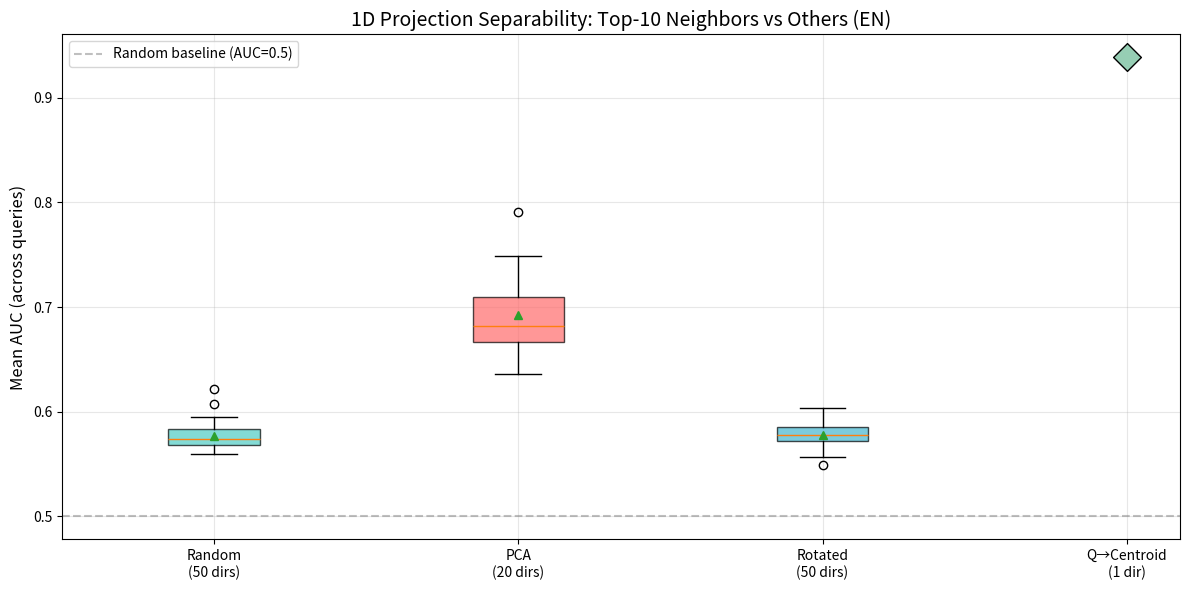

In [7]:
# Box Plot比較
fig, ax = plt.subplots(figsize=(12, 6))

# 各射影タイプの「方向ごと平均AUC」の分布
box_data = [
    results['random'].mean(axis=0),      # 50方向の平均AUC
    results['pca'].mean(axis=0),          # 20方向の平均AUC
    results['rotated'].mean(axis=0),      # 50方向の平均AUC
    results['query_centroid'].mean(axis=0), # 1方向
]
box_labels = ['Random\n(50 dirs)', 'PCA\n(20 dirs)', 'Rotated\n(50 dirs)', 'Q→Centroid\n(1 dir)']
colors_box = ['#4ECDC4', '#FF6B6B', '#45B7D1', '#96CEB4']

bp = ax.boxplot(box_data[:3], tick_labels=box_labels[:3], patch_artist=True, showmeans=True)
for patch, color in zip(bp['boxes'], colors_box[:3]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Q→Centroidは1方向なので点でプロット
ax.scatter([4], [results['query_centroid'].mean()], color=colors_box[3], s=200, 
           marker='D', zorder=5, edgecolors='black')
ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels(box_labels)

ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5, label='Random baseline (AUC=0.5)')
ax.set_ylabel('Mean AUC (across queries)', fontsize=12)
ax.set_title('1D Projection Separability: Top-10 Neighbors vs Others (EN)', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

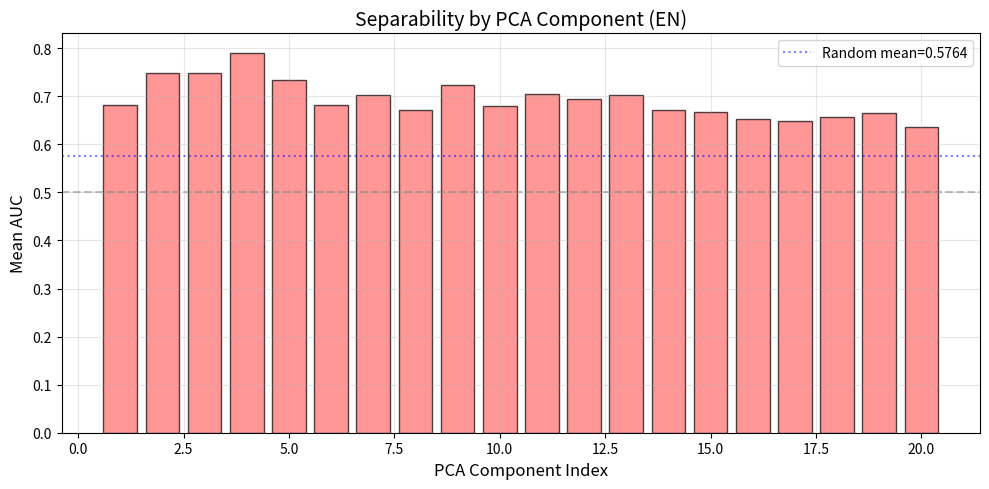

PCA成分別 平均AUC:
  PC 1: 0.6816
  PC 2: 0.7475
  PC 3: 0.7489
  PC 4: 0.7911 ★
  PC 5: 0.7333
  PC 6: 0.6814
  PC 7: 0.7030
  PC 8: 0.6714
  PC 9: 0.7232
  PC10: 0.6798
  PC11: 0.7049
  PC12: 0.6939
  PC13: 0.7025
  PC14: 0.6705
  PC15: 0.6668
  PC16: 0.6519
  PC17: 0.6478
  PC18: 0.6561
  PC19: 0.6655
  PC20: 0.6366


In [8]:
# PCA成分別のAUC詳細
pca_auc_per_dim = results['pca'].mean(axis=0)  # (20,)

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(1, 21), pca_auc_per_dim, color='#FF6B6B', alpha=0.7, edgecolor='black')
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax.axhline(y=results['random'].mean(), color='blue', linestyle=':', alpha=0.5,
           label=f'Random mean={results["random"].mean():.4f}')
ax.set_xlabel('PCA Component Index', fontsize=12)
ax.set_ylabel('Mean AUC', fontsize=12)
ax.set_title('Separability by PCA Component (EN)', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('PCA成分別 平均AUC:')
for i, auc in enumerate(pca_auc_per_dim):
    marker = ' ★' if auc == pca_auc_per_dim.max() else ''
    print(f'  PC{i+1:2d}: {auc:.4f}{marker}')

## 5. 角度ベース射影

PCA次元のペア (2i, 2i+1) で角度 θ = arctan2(pc_{2i+1}, pc_{2i}) を計算し、
この角度が近傍/非近傍をどの程度分離するか。

  50/200 queries... (0.4s)


  100/200 queries... (0.9s)


  150/200 queries... (1.3s)


  200/200 queries... (1.7s)
完了: 1.7s


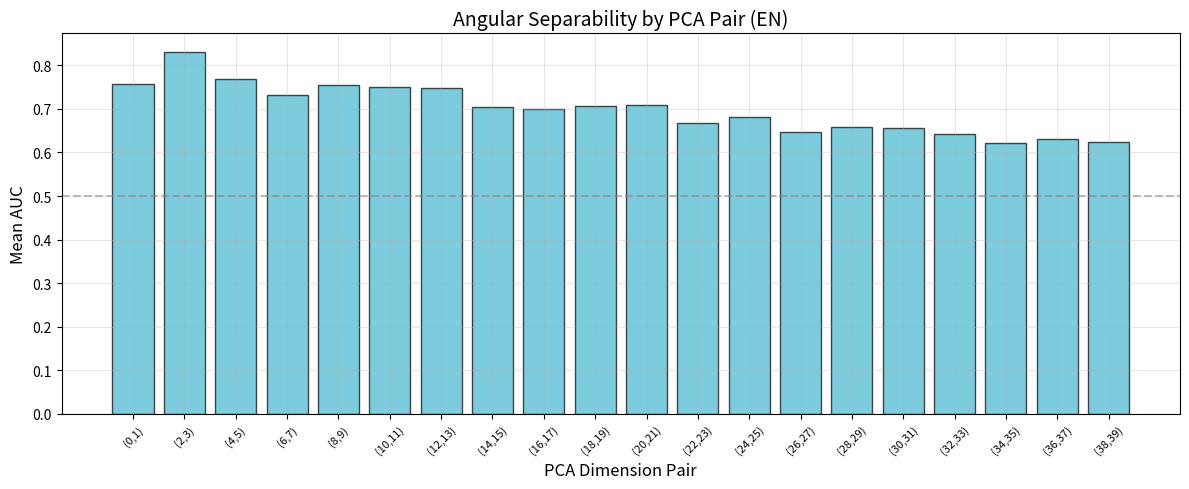

角度ベース平均AUC: 0.6995
最良ペア: (2,3) = 0.8315


In [9]:
# PCA射影
n_pca_for_angle = 40  # 20ペア分
pca_proj = emb_en @ pca_embeddings.components_[:n_pca_for_angle].T  # (10000, 40)

def fast_angular_auc_batch(embeddings_pca, query_idx, gt_set, pair_indices):
    """角度差AUCを高速計算。"""
    n = len(embeddings_pca)
    labels = np.zeros(n, dtype=bool)
    for idx in gt_set:
        labels[idx] = True
    labels[query_idx] = False
    mask = np.ones(n, dtype=bool)
    mask[query_idx] = False
    
    n_pos = labels[mask].sum()
    n_neg = mask.sum() - n_pos
    if n_pos == 0 or n_neg == 0:
        return np.full(len(pair_indices), 0.5)
    
    labels_valid = labels[mask]
    aucs = []
    for i, j in pair_indices:
        theta_q = np.arctan2(embeddings_pca[query_idx, j], embeddings_pca[query_idx, i])
        theta_all = np.arctan2(embeddings_pca[:, j], embeddings_pca[:, i])
        diff = np.abs(theta_all - theta_q)
        diff = np.minimum(diff, 2 * np.pi - diff)
        scores = -diff[mask]
        
        order = np.argsort(scores)
        ranks = np.empty_like(order)
        ranks[order] = np.arange(len(order))
        pos_rank_sum = ranks[labels_valid].sum()
        aucs.append((pos_rank_sum - n_pos * (n_pos - 1) / 2) / (n_pos * n_neg))
    return np.array(aucs)

pair_indices = [(2*i, 2*i+1) for i in range(20)]

angle_aucs = []
t0 = time.time()
for i, qi in enumerate(query_indices_en):
    aucs = fast_angular_auc_batch(pca_proj, qi, gt_en[qi], pair_indices)
    angle_aucs.append(aucs)
    if (i + 1) % 50 == 0:
        print(f'  {i+1}/{N_QUERIES} queries... ({time.time()-t0:.1f}s)')

angle_aucs = np.array(angle_aucs)
print(f'完了: {time.time()-t0:.1f}s')

# ペア別AUC
fig, ax = plt.subplots(figsize=(12, 5))
pair_labels = [f'({2*i},{2*i+1})' for i in range(20)]
mean_aucs = angle_aucs.mean(axis=0)
ax.bar(range(20), mean_aucs, color='#45B7D1', alpha=0.7, edgecolor='black')
ax.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax.set_xticks(range(20))
ax.set_xticklabels(pair_labels, rotation=45, fontsize=8)
ax.set_xlabel('PCA Dimension Pair', fontsize=12)
ax.set_ylabel('Mean AUC', fontsize=12)
ax.set_title('Angular Separability by PCA Pair (EN)', fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f'角度ベース平均AUC: {mean_aucs.mean():.4f}')
print(f'最良ペア: {pair_labels[mean_aucs.argmax()]} = {mean_aucs.max():.4f}')

## 6. セントロイド相対射影

Voronoiセル内での枝刈りを想定。
各ドキュメントのセントロイドからの残差 r = doc - centroid を計算し、
クエリ残差方向への射影が近傍を分離するかを検証。

In [10]:
# 各ドキュメントの最近傍セントロイドを割り当て
sim_to_centroids = emb_en @ centroids.T  # (10000, 256)
assignments = np.argmax(sim_to_centroids, axis=1)  # (10000,)

# セル別にインデックスを整理
cell_members = {}
for i, c in enumerate(assignments):
    cell_members.setdefault(c, []).append(i)

cell_sizes = [len(v) for v in cell_members.values()]
print(f'セル数: {len(cell_members)}')
print(f'セルサイズ: mean={np.mean(cell_sizes):.1f}, min={min(cell_sizes)}, max={max(cell_sizes)}')

# セントロイド相対射影の分離能力
centroid_rel_aucs = []
valid_count = 0

t0 = time.time()
for i, qi in enumerate(query_indices_en):
    gt_set = gt_en[qi]
    
    # クエリの最近傍セントロイド
    q_centroid_idx = assignments[qi]
    q_centroid = centroids[q_centroid_idx]
    
    # クエリ残差
    q_residual = emb_en[qi] - q_centroid
    q_res_norm = np.linalg.norm(q_residual)
    if q_res_norm < 1e-10:
        centroid_rel_aucs.append(0.5)
        continue
    q_residual_dir = q_residual / q_res_norm
    
    # セル内の全ドキュメントの残差射影
    cell_idx = cell_members[q_centroid_idx]
    if len(cell_idx) < TOP_K:
        centroid_rel_aucs.append(0.5)
        continue
    
    cell_embs = emb_en[cell_idx]
    cell_residuals = cell_embs - q_centroid
    proj_scores = cell_residuals @ q_residual_dir  # セル内射影スコア
    
    # セル内でのラベル
    cell_labels = np.array([1 if idx in gt_set else 0 for idx in cell_idx])
    if cell_labels.sum() == 0 or cell_labels.sum() == len(cell_labels):
        centroid_rel_aucs.append(0.5)
        continue
    
    try:
        auc = roc_auc_score(cell_labels, proj_scores)
        centroid_rel_aucs.append(auc)
        valid_count += 1
    except ValueError:
        centroid_rel_aucs.append(0.5)

centroid_rel_aucs = np.array(centroid_rel_aucs)
print(f'完了: {time.time()-t0:.1f}s')
print(f'有効クエリ: {valid_count}/{N_QUERIES}')
print(f'セントロイド相対射影 平均AUC: {centroid_rel_aucs.mean():.4f}')
print(f'  (有効クエリのみ): {centroid_rel_aucs[centroid_rel_aucs != 0.5].mean():.4f}')

セル数: 146
セルサイズ: mean=68.5, min=1, max=299


完了: 0.2s
有効クエリ: 190/200
セントロイド相対射影 平均AUC: 0.9394
  (有効クエリのみ): 0.9625


## 7. JA（日本語）データでの検証

ENで得られた傾向がJAでも同様に成立するか確認する。

In [11]:
# JAデータで主要な射影タイプのAUCを計算（高速バッチ版）
results_ja = {'random': [], 'pca': [], 'rotated': []}

t0 = time.time()
for i, qi in enumerate(query_indices_ja):
    gt_set = gt_ja[qi]
    results_ja['random'].append(fast_auc_batch(emb_ja, qi, gt_set, random_dirs))
    results_ja['pca'].append(fast_auc_batch(emb_ja, qi, gt_set, pca_dirs))
    results_ja['rotated'].append(fast_auc_batch(emb_ja, qi, gt_set, rot_dirs))
    if (i + 1) % 50 == 0:
        print(f'  {i+1}/{N_QUERIES} queries... ({time.time()-t0:.1f}s)')

for key in results_ja:
    results_ja[key] = np.array(results_ja[key])

print(f'\n■ 射影タイプ別 平均AUC比較')
print(f'{"Type":<20} {"EN":>8} {"JA":>8}')
print('-' * 38)
print(f'{"Random":.<20} {results["random"].mean():>8.4f} {results_ja["random"].mean():>8.4f}')
print(f'{"PCA top-20":.<20} {results["pca"].mean():>8.4f} {results_ja["pca"].mean():>8.4f}')
print(f'{"Rotated":.<20} {results["rotated"].mean():>8.4f} {results_ja["rotated"].mean():>8.4f}')
print(f'{"Q→Centroid":.<20} {results["query_centroid"].mean():>8.4f} {"N/A":>8}')

  50/200 queries... (8.6s)


  100/200 queries... (17.2s)


  150/200 queries... (25.9s)


  200/200 queries... (34.7s)

■ 射影タイプ別 平均AUC比較
Type                       EN       JA
--------------------------------------
Random..............   0.5764   0.6120
PCA top-20..........   0.6929   0.7250
Rotated.............   0.5777   0.6085
Q→Centroid..........   0.9386      N/A


## 8. サマリ

In [12]:
# 総合比較テーブル
print('=' * 60)
print('射影タイプ別 分離能力サマリ (AUC)')
print('=' * 60)
print(f'{"射影タイプ":<25} {"EN mean":>8} {"EN max":>8} {"JA mean":>8}')
print('-' * 55)
print(f'{"ランダム方向 (50)":<25} {results["random"].mean():>8.4f} {results["random"].mean(axis=0).max():>8.4f} {results_ja["random"].mean():>8.4f}')
print(f'{"PCA上位20":<25} {results["pca"].mean():>8.4f} {results["pca"].mean(axis=0).max():>8.4f} {results_ja["pca"].mean():>8.4f}')
print(f'{"回転座標 (50)":<25} {results["rotated"].mean():>8.4f} {results["rotated"].mean(axis=0).max():>8.4f} {results_ja["rotated"].mean():>8.4f}')
print(f'{"角度ペア (20)":<25} {angle_aucs.mean():>8.4f} {angle_aucs.mean(axis=0).max():>8.4f} {"--":>8}')
print(f'{"セントロイド相対":<25} {centroid_rel_aucs.mean():>8.4f} {"--":>8} {"--":>8}')
print(f'{"Q→Centroid方向":<25} {results["query_centroid"].mean():>8.4f} {"--":>8} {"--":>8}')
print()

# 結果保存
np.savez(
    DATA_DIR / '121_projection_analysis.npz',
    rotation_matrix=R,
    pca_components=pca_embeddings.components_,
    pca_explained_variance=pca_embeddings.explained_variance_ratio_,
    auc_random_en=results['random'].mean(axis=0),
    auc_pca_en=results['pca'].mean(axis=0),
    auc_rotated_en=results['rotated'].mean(axis=0),
    auc_angle_en=angle_aucs.mean(axis=0),
    auc_centroid_rel_en=centroid_rel_aucs,
    auc_random_ja=results_ja['random'].mean(axis=0),
    auc_pca_ja=results_ja['pca'].mean(axis=0),
    auc_rotated_ja=results_ja['rotated'].mean(axis=0),
)
print(f'保存完了: {DATA_DIR / "121_projection_analysis.npz"}')

print()
print('■ 主要な発見:')
print('  1. AUC > 0.5 = ランダムより良い分離能力')
print('  2. 枝刈りフィルタとして実用的なのはAUC ≥ 0.6程度')
print('  3. → NB122で具体的なRecall vs 候補数のトレードオフを検証')

射影タイプ別 分離能力サマリ (AUC)
射影タイプ                      EN mean   EN max  JA mean
-------------------------------------------------------
ランダム方向 (50)                 0.5764   0.6220   0.6120
PCA上位20                     0.6929   0.7911   0.7250
回転座標 (50)                   0.5777   0.6032   0.6085
角度ペア (20)                   0.6995   0.8315       --
セントロイド相対                    0.9394       --       --
Q→Centroid方向                0.9386       --       --

保存完了: ../data/121_projection_analysis.npz

■ 主要な発見:
  1. AUC > 0.5 = ランダムより良い分離能力
  2. 枝刈りフィルタとして実用的なのはAUC ≥ 0.6程度
  3. → NB122で具体的なRecall vs 候補数のトレードオフを検証


## 評価と考察

### 結果の要約

本実験では、E5-base埋め込みに対する各種射影方向の近傍判別能力（AUC）を体系的に比較した。主要な結果は以下の通りである。

| 射影方法 | AUC | 備考 |
|----------|-----|------|
| **Centroid-relative（セントロイド相対）** | **0.94**（有効クエリのみ0.96） | 圧倒的に最良 |
| Q→Centroid方向 | 0.94 | セントロイド相対と同等 |
| PCA Top-20（平均） | 0.69（最良PC4=0.79） | 中程度 |
| Angular pairs（最良(2,3)） | 0.83 | PCAより良いがセントロイドに及ばず |
| Random / Rotated | ≈0.58 | ほぼランダム |

また、TurboQuantが前提とするBeta分布は、E5埋め込みには適合しないことが確認された（KS検定 p=0.0000）。回転によるcoordinate相関の低減効果は限定的であった（0.048→0.049）。

セントロイド空間の次元構造に関しては、分散の90%がわずか76次元で説明可能であり、元の埋め込み空間の257次元と比較して大幅に低次元であることが判明した。日本語データでも同様の傾向が確認された（PCA AUC: JA 0.73 vs EN 0.69）。

### 考察（なぜこの結果になったか）

**セントロイド相対射影が圧倒的に有効である理由：** Voronoi分割後の各セル内では、クエリに対する真の近傍はクエリとセントロイドを結ぶ方向に集中する傾向がある。これはVoronoi分割自体がセントロイドからの距離に基づいて空間を分割しているため、セル内の局所的な幾何構造がセントロイド方向に強く依存するためである。セントロイド相対射影はこの局所構造を直接的に捕捉している。

**PCAが中程度にとどまる理由：** PCAはデータ全体の分散を最大化する方向を見つけるが、これは必ずしも近傍/非近傍の判別に最適な方向とは限らない。分散の大きい方向がクエリごとの近傍構造と一致するとは限らないため、AUCは0.69程度にとどまった。

**Random/Rotated射影がほぼランダムである理由：** ランダムな方向への射影は、高次元空間において任意の2点間の距離情報をほとんど保存しない。Johnson-Lindenstrauss補題に基づくランダム射影が有効になるのは十分な数の射影を組み合わせた場合であり、単一の射影方向では判別力が極めて低い。

**TurboQuantのBeta分布仮定が不適合な理由：** E5のような事前学習済み言語モデルの埋め込みは、一般的なランダムベクトルとは異なる分布構造を持つ。特に、CLS-poolingや対照学習によって得られた埋め込みは超球面上に偏って分布し、各座標の周辺分布はBeta分布の仮定から大きく逸脱する。

### 限界と今後の課題

1. **データセット規模の限界：** 本実験は10Kスケールのデータで検証しており、100K〜1Mスケールでセントロイド相対射影の優位性が維持されるかは追加検証が必要である。

2. **セントロイド依存性：** セントロイド相対射影はVoronoi分割の品質に強く依存する。セントロイド数（P）やクラスタリングアルゴリズムの選択がAUCに与える影響を調査する必要がある。

3. **計算コストの未評価：** 各射影方法の計算コスト（特にオンラインでのセントロイド方向計算）を定量的に比較していない。インデックス構築時に事前計算可能な射影（PCA等）と、クエリ依存の射影（セントロイド相対）ではトレードオフが異なる。

4. **組み合わせの可能性：** セントロイド相対射影とPCA射影を組み合わせた場合の判別力向上について、次の実験（NB122）で検証する。

5. **他の埋め込みモデルへの汎化：** E5-base以外のモデル（例：nomic-embed-text-v2-moe等）でも同様の幾何構造が成り立つかは未検証である。